# Tutorial 3: Large rasters

This tutorial demonstrates `floodsr` with a larger low-res flood raster and an end-to-end CLI run that fetches HRDEM and writes the super-resolved output in one shot.

**What you'll do:**
- verify the extended install from {ref}`extended_install`
- download and visualize a larger test raster
- run `floodsr tohr` with `--fetch-hrdem`
- inspect both the fetched HRDEM and final output


## Install `floodsr`

This tutorial requires the extended install described in {ref}`extended_install`.
If you followed the instructions for the {ref}`basic_install`, the simplest way to upgrade is to install a new environment per {ref}`extended_install`.
And you should probably uninstall the old/previous **basic** environment to avoid confusion and free up disk space.

Proceed with {ref}`extended_install` based on your execution context:
- **command line (CLI)**: copy and paste the commands from {ref}`extended_install_cli` into your terminal.
- **local notebook (Jupyter)**: follow the same extended install as for the CLI, then run the additional steps from {ref}`extended_install_notebook` so this notebook uses the correct kernel.
- **hosted notebook (Colab)**: Probably a bad idea. but see {ref}`extended_install_hosted_notebook`, or uncomment the experimental setup cell below if you're feeling brave.


In [1]:
# Colab experimental setup
# !apt-get update -qq
# !apt-get install -y -qq gdal-bin libgdal-dev
# !pip install -q --upgrade pip
# !pip install -q "gdal[numpy]==$(gdal-config --version).*" rasterio geopandas pyproj shapely fiona
# !pip install -q floodsr


## Install additional packages

For this tutorial, we need the additional Python packages `matplotlib` and `rasterio` as shown in {doc}`Tutorial 2 <tutorial_2>`


After you've done this, check versions:

In [2]:
import matplotlib
import rasterio

print(f"matplotlib=={matplotlib.__version__}")
print(f"rasterio=={rasterio.__version__}")

matplotlib==3.10.8
rasterio==1.5.0


## Imports

In [3]:
import os
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.enums import Resampling


## Set Cache

When rasters become large, caching downloads to disk can be a huge time saver. 

By default, this notebook follows the same cache behavior as the source code: if no cache override is supplied, `floodsr` uses its normal platform cache location.

If you want to override that behavior, edit the below cell and set `base_cache_dir` to a path you want `floodsr` to reuse.

In [4]:
# Edit this cell if you want to override the default cache behavior.
base_cache_dir = os.getenv("FLOODSR_SHARED_CACHE_DIR")
if base_cache_dir is not None:
    base_cache_dir = Path(base_cache_dir).expanduser().resolve()
    base_cache_dir.mkdir(parents=True, exist_ok=True)


if base_cache_dir is None:
    print("cache_dir=None -> floodsr will use its default platform cache")
else:
    print(f"cache_dir={base_cache_dir}")

cache_dir=/home/cefect/LS/09_REPOS/04_TOOLS/floodsr/_cache


## Set Output Paths

In [5]:
# Define the low-res input name and the derived output paths.
lowres_name = "inunriver_historical_000000000WATCH_1980_rp01000.tif"
hrdem_fp = Path(f"{Path(lowres_name).stem}_fetched_hrdem.vrt").resolve()
result_fp = Path("result.tif").resolve()

print(f"hrdem_fp={hrdem_fp}")
print(f"result_fp={result_fp}")

hrdem_fp=/home/cefect/LS/10_IO/2407_FHIMP/tmp/floodsr-tutorial_3-RB024y/run/inunriver_historical_000000000WATCH_1980_rp01000_fetched_hrdem.vrt
result_fp=/home/cefect/LS/10_IO/2407_FHIMP/tmp/floodsr-tutorial_3-RB024y/run/result.tif


## Download Test Data

We use a clipped tile from the old [Aqueduct Floods Hazard Maps](https://wri-projects.s3.amazonaws.com/AqueductFloodTool/download/v2/index.html) dataset.


In [6]:
lowres_fp = Path(lowres_name).resolve()

urlretrieve(
    "https://github.com/cefect/floodsr/releases/download/v0.0.9/inunriver_historical_000000000WATCH_1980_rp01000.tif",
    lowres_fp,
)
assert lowres_fp.is_file(), f"could not find {lowres_fp}"

## Plot the Low-Res Input

LR depth shape: (30, 60)


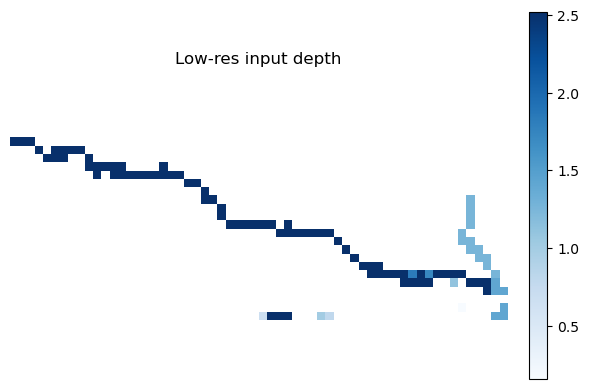

In [7]:
with rasterio.open(lowres_fp) as src:
    lowres = src.read(1).astype(float)
    if src.nodata is not None:
        lowres[lowres == src.nodata] = np.nan

plt.figure(figsize=(6, 4))
im = plt.imshow(np.where(lowres > 0, lowres, np.nan), cmap="Blues")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title("Low-res input depth")
plt.axis("off")
plt.tight_layout()

print(f"LR depth shape: {lowres.shape}")

yuck

## Fetch HRDEM and Run `tohr`

For this larger example, we use one CLI command to fetch HRDEM, resolve the model, and run super-resolution in one shot.
The fetched HRDEM is projected (`EPSG:3979`) while the low-res depth raster is geographic (`EPSG:4326`), so we pass `--crs-policy=use-dem` to reproject the depth raster onto the DEM grid.
The `--fetch-out` argument keeps a copy of the fetched HRDEM so we can inspect it in the next section.

If you left `base_cache_dir` as `None`, this command uses the default `floodsr` cache location.


In [8]:
# Run the one-shot fetch + super-resolution command through the notebook CLI.
cache_dir_arg = "" if base_cache_dir is None else f" --cache-dir {base_cache_dir}"
!floodsr tohr --in {lowres_fp} -f --fetch-out inunriver_historical_000000000WATCH_1980_rp01000_fetched_hrdem.vrt --fetch-force-tiling{cache_dir_arg} --crs-policy use-dem --model-version ResUNet_16x_DEM --out result.tif --min-depth-threshold=0.1


INFO:__main__:starting DEM fetch
  source_id=hrdem
  stac_url=https://datacube.services.geo.ca/api
  collection=hrdem-mosaic-1m
  asset_key=dtm
  gdal_available=True
  force_tiling=True
  fetch_window_size=8192
  memory_limit_gib=16.00
  stac_query_limit=200
  use_project_extent_filter=True
  use_cache=True
  cache_dir=/home/cefect/LS/09_REPOS/04_TOOLS/floodsr/_cache
  show_progress=True
  project_extent_url=https://maps-cartes.services.geo.ca/server_serveur/rest/services/NRCan/coverage_HRDEM_en/MapServer/4
  depth_lr_fp=
    /home/cefect/LS/10_IO/2407_FHIMP/tmp/floodsr-tutorial_3-RB024y/run/inunriver_historical_000000000WATCH_1980_rp01000.tif


INFO:__main__:found 1 HRDEM item(s) intersecting low-res tile bounds after exact intersection filter
INFO:__main__:raw fetch request grid: width=41,378, height=36,698, pixels=1,518,489,844, non_windowed_peak_estimate=19.09 GiB
INFO:__main__:HRDEM tile cache state: enabled=1, dir=/home/cefect/LS/09_REPOS/04_TOOLS/floodsr/_cache/floodsr_hrdem_tile_cache, existing_files=30, request_token=efe01d715bf4e2c5fa58b4c7


INFO:__main__:window tiling plan: source_window_shape=8,192 x 8,192, source_grid=5x6, tiles_total=30, full_tiles=20, edge_tiles=10


INFO:__main__:downloaded 6 HRDEM project extent feature(s) for clip_bounds_3979=(-1337991.5909947976, 418972.1146557964, -1296614.5561817389, 455669.36264035257), raster_shape=(36698, 41378), cache=none


HRDEM window fetch:   0%|                              | 0/30 [00:00<?, ?tile/s]

...

final write pass:  96%|█████████████▍| 22402/23328 [00:05<00:00, 4341.52block/s]

final write pass:  98%|█████████████▋| 22837/23328 [00:05<00:00, 4272.16block/s]

final write pass: 100%|██████████████| 23328/23328 [00:05<00:00, 4269.16block/s]


INFO:__main__:finished tohr inference in 47.645s; wrote 6,115,575,724 bytes to
    /home/cefect/LS/10_IO/2407_FHIMP/tmp/floodsr-tutorial_3-RB024y/run/result.tif


/home/cefect/LS/10_IO/2407_FHIMP/tmp/floodsr-tutorial_3-RB024y/run/result.tif


In [ ]:
# Check that the expected output raster exists.
assert Path("result.tif").is_file(), "missing output raster\n    result.tif"


## Visualize the Fetched HRDEM

The previous command wrote the fetched HRDEM to `--fetch-out`, so we can inspect the DEM tile directly.


DEM full shape: (36698, 41378)
DEM preview shape: (908, 1024)


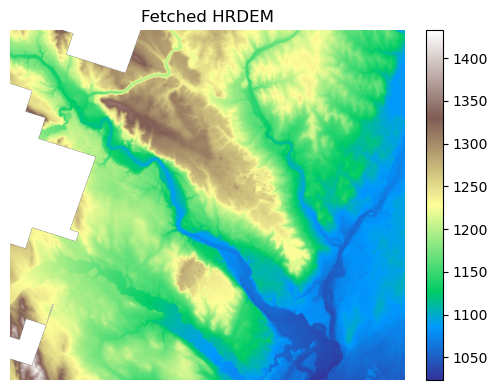

In [9]:
with rasterio.open(hrdem_fp) as src:
    preview_scale = max(src.height / 1024, src.width / 1024, 1)
    preview_shape = (
        max(1, int(src.height / preview_scale)),
        max(1, int(src.width / preview_scale)),
    )
    dem = src.read(1, out_shape=preview_shape, resampling=Resampling.bilinear).astype(float)
    if src.nodata is not None:
        dem[dem == src.nodata] = np.nan

plt.figure(figsize=(6, 4))
im = plt.imshow(dem, cmap="terrain")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title("Fetched HRDEM")
plt.axis("off")
plt.tight_layout()

print(f"DEM full shape: {src.shape}")
print(f"DEM preview shape: {dem.shape}")

## Visualize the Output

Output full shape: (36698, 41378)
Output preview shape: (908, 1024)


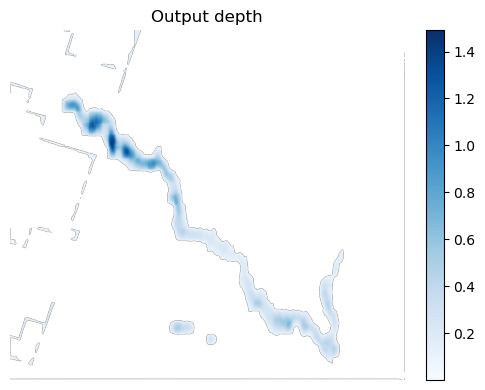

In [10]:
with rasterio.open(result_fp) as src:
    preview_scale = max(src.height / 1024, src.width / 1024, 1)
    preview_shape = (
        max(1, int(src.height / preview_scale)),
        max(1, int(src.width / preview_scale)),
    )
    result = src.read(1, out_shape=preview_shape, resampling=Resampling.bilinear).astype(float)
    if src.nodata is not None:
        result[result == src.nodata] = np.nan

plt.figure(figsize=(6, 4))
im = plt.imshow(np.where(result > 0, result, np.nan), cmap="Blues")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title("Output depth")
plt.axis("off")
plt.tight_layout()

print(f"Output full shape: {src.shape}")
print(f"Output preview shape: {result.shape}")